# 02 — Segmentation RFM et leviers de rétention

**Question métier :** quels clients génèrent la valeur, lesquels sont en train de partir, et quel levier activer pour faire revenir des clients qui, pour la très grande majorité, n'achètent qu'une fois ?

**Méthode :** les scores et segments sont calculés en SQL dans la vue [`rfm_customer_segments`](../sql/02_rfm_views.sql). Ce notebook les lit depuis PostgreSQL, les valide et les interprète.

| Dimension | Définition | Score |
|---|---|---|
| **R**écence | jours entre le dernier achat et le 29/08/2018 | quintiles (5 = le plus récent) |
| **F**réquence | nombre de commandes livrées | seuils : 1 → 1, 2 → 3, 3-4 → 4, 5+ → 5 |
| **M**ontant | total payé en R$ (produits + livraison) | quintiles (5 = le plus élevé) |

**Règles de segmentation (Récence × Montant)**

| Segment | Règle | Lecture métier |
|---|---|---|
| Champions | R ≥ 4 et M ≥ 4 | récents et à forte valeur |
| Potential Loyalists | R ≥ 3 et M ≥ 3 | récents et à valeur moyenne à forte |
| New Customers | R ≥ 4 et M ≤ 2 | récents mais à faible panier |
| At Risk | R ≤ 2 et M ≥ 4 | forte valeur, mais inactifs depuis > 9 mois |
| Lost | R ≤ 2 et M ≤ 2 | anciens et à faible valeur |
| Need Attention | autres cas | profil intermédiaire |

**Plan :** 1. Distributions RFM · 2. Grille de segmentation · 3. Poids des segments · 4. Réachat · 5. Satisfaction · 6. Géographie et catégories · 7. Conclusions

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import chi2_contingency

sys.path.append(str(Path.cwd().parent / "src"))
from config import FIGURES_DIR, get_engine

BLUE, ORANGE, GREY = "#2a78d6", "#eb6834", "#8a8983"
BLUES = LinearSegmentedColormap.from_list("blues", ["#cde2fb", "#6da7ec", "#256abf", "#0d366b"])
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.color": "#e6e5e1",
    "axes.axisbelow": True,
    "axes.edgecolor": GREY,
    "axes.labelcolor": "#52514e",
    "xtick.color": "#52514e",
    "ytick.color": "#52514e",
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.titlelocation": "left",
})
pd.set_option("display.float_format", "{:,.2f}".format)

SEGMENT_ORDER = ["Champions", "Potential Loyalists", "At Risk", "Need Attention", "New Customers", "Lost"]

engine = get_engine()
rfm = pd.read_sql("SELECT * FROM rfm_customer_segments", engine)
print(f"{len(rfm):,} clients, {rfm['monetary'].sum():,.0f} R$ de chiffre d'affaires")
rfm.head()

93,357 clients, 15,422,462 R$ de chiffre d'affaires


,customer_unique_id,customer_state,recency,frequency,monetary,r_score,f_score,m_score,rfm_total,rfm_code,segment,is_repeat_customer
0,10e89fd8e5c745f81bec101207ba4d7d,MG,695,1,92.27,1,1,3,5,113,Need Attention,False
1,2f64e403852e6893ae37485d5fcacdaf,RS,695,1,39.09,1,1,1,3,111,Lost,False
2,61db744d2f835035a5625b59350c6b63,RS,695,1,53.73,1,1,1,3,111,Lost,False
3,87776adb449c551e74c13fc34f036105,SP,695,1,40.95,1,1,1,3,111,Lost,False
4,7390ed59fa1febbfda31a80b4318c8cb,GO,695,1,154.57,1,1,4,6,114,At Risk,False


### Contrôles de cohérence
Avant d'interpréter, on vérifie que la vue est correcte : un client par ligne, des scores dans [1, 5], des quintiles équilibrés et un chiffre d'affaires cohérent avec les paiements.

In [2]:
total_payments = pd.read_sql(
    """
    SELECT SUM(p.payment_value) AS total
    FROM payments AS p
    JOIN orders AS o USING (order_id)
    WHERE o.order_status = 'delivered'
    """,
    engine,
)["total"].iloc[0]

assert rfm["customer_unique_id"].is_unique
assert rfm[["r_score", "f_score", "m_score"]].isin(range(1, 6)).all().all()
assert np.isclose(rfm["monetary"].sum(), total_payments)

rfm[["r_score", "m_score"]].apply(lambda s: s.value_counts(normalize=True).sort_index()).mul(100).round(1)

,r_score,m_score
1,19.90,20.00
2,19.80,20.00
3,20.10,20.00
4,20.10,20.00
5,20.10,20.00


Les quintiles R et M contiennent chacun environ 20 % des clients. Le scoring utilise `CUME_DIST` plutôt que `NTILE` : deux clients ayant la même récence obtiennent toujours le même score, ce qui rend la segmentation **déterministe** et reproductible d'une exécution à l'autre.

## 1. Distributions R, F, M

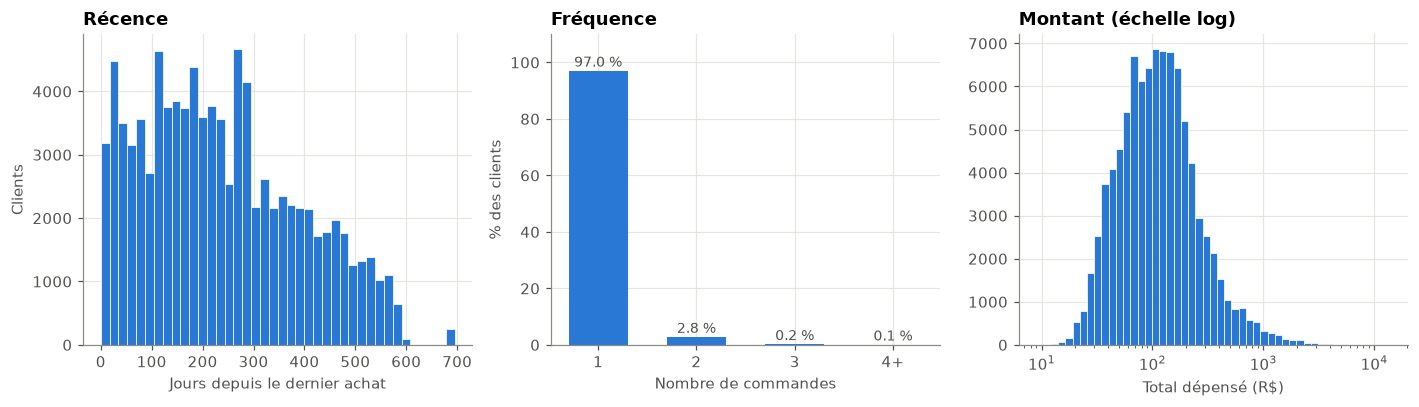

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))

axes[0].hist(rfm["recency"], bins=40, color=BLUE, edgecolor="white", linewidth=0.5)
axes[0].set_title("Récence")
axes[0].set_xlabel("Jours depuis le dernier achat")
axes[0].set_ylabel("Clients")

freq_share = rfm["frequency"].clip(upper=4).value_counts(normalize=True).sort_index() * 100
axes[1].bar(["1", "2", "3", "4+"], freq_share.values, color=BLUE, width=0.6)
for x, v in enumerate(freq_share.values):
    axes[1].text(x, v + 1.5, f"{v:.1f} %", ha="center", color="#52514e", fontsize=9)
axes[1].set_title("Fréquence")
axes[1].set_xlabel("Nombre de commandes")
axes[1].set_ylabel("% des clients")
axes[1].set_ylim(0, 110)

axes[2].hist(rfm["monetary"], bins=np.geomspace(9, 14_000, 50), color=BLUE, edgecolor="white", linewidth=0.5)
axes[2].set_xscale("log")
axes[2].set_title("Montant (échelle log)")
axes[2].set_xlabel("Total dépensé (R$)")

fig.tight_layout()
plt.show()

**Interprétation**
- **Récence** : répartie de façon assez uniforme sur ~2 ans, ce qui en fait une bonne dimension discriminante.
- **Fréquence** : 97 % des clients ont acheté une seule fois. La dimension F discrimine très peu, ce qui justifie une segmentation fondée sur R × M.
- **Montant** : distribution log-normale avec une longue traîne. Les 20 % de clients les plus dépensiers génèrent **54 % du chiffre d'affaires**.

## 2. Grille de segmentation Récence × Montant

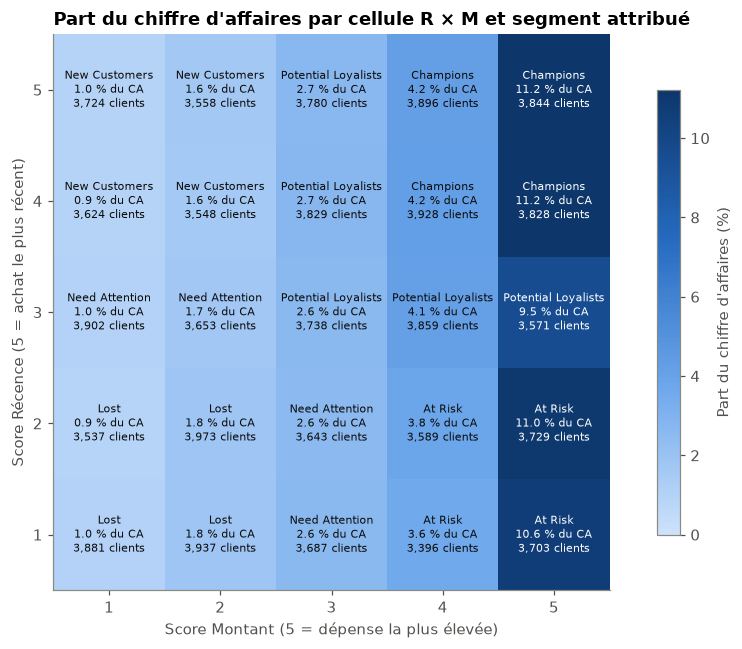

In [4]:
grid = rfm.groupby(["r_score", "m_score"]).agg(
    clients=("customer_unique_id", "count"),
    revenue=("monetary", "sum"),
    segment=("segment", "first"),
)
grid["pct_revenue"] = 100 * grid["revenue"] / grid["revenue"].sum()
revenue_share = grid["pct_revenue"].unstack().sort_index(ascending=False)
labels = grid["segment"].unstack().sort_index(ascending=False)
clients = grid["clients"].unstack().sort_index(ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
ax.grid(False)
image = ax.imshow(revenue_share.values, cmap=BLUES, vmin=0)
for i in range(5):
    for j in range(5):
        share = revenue_share.iat[i, j]
        color = "white" if share > revenue_share.values.max() / 2 else "#0b0b0b"
        ax.text(j, i, f"{labels.iat[i, j]}\n{share:.1f} % du CA\n{clients.iat[i, j]:,} clients",
                ha="center", va="center", fontsize=7.5, color=color)
ax.set_xticks(range(5), revenue_share.columns)
ax.set_yticks(range(5), revenue_share.index)
ax.set_xlabel("Score Montant (5 = dépense la plus élevée)")
ax.set_ylabel("Score Récence (5 = achat le plus récent)")
ax.set_title("Part du chiffre d'affaires par cellule R × M et segment attribué")
fig.colorbar(image, ax=ax, label="Part du chiffre d'affaires (%)", shrink=0.8)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "rfm_grid.png", bbox_inches="tight")
plt.show()

Chaque cellule R × M appartient à un seul segment et contient environ 4 % des clients (quintiles équilibrés, R et M quasi indépendants). **Le chiffre d'affaires, lui, est concentré dans la colonne M = 5** : les 20 % de clients les plus dépensiers génèrent 54 % du revenu, quelle que soit leur récence. C'est ce qui rend le segment At Risk (M ≥ 4, R ≤ 2) si coûteux à perdre.

## 3. Poids des segments : clients vs chiffre d'affaires

In [5]:
segments = (
    rfm.groupby("segment")
    .agg(
        nb_clients=("customer_unique_id", "count"),
        recence_mediane=("recency", "median"),
        montant_moyen=("monetary", "mean"),
        montant_median=("monetary", "median"),
        taux_reachat=("is_repeat_customer", "mean"),
        revenu=("monetary", "sum"),
    )
    .reindex(SEGMENT_ORDER)
)
segments["pct_clients"] = 100 * segments["nb_clients"] / segments["nb_clients"].sum()
segments["pct_revenu"] = 100 * segments["revenu"] / segments["revenu"].sum()
segments["taux_reachat"] *= 100
segments

,nb_clients,recence_mediane,montant_moyen,montant_median,taux_reachat,revenu,pct_clients,pct_revenu
segment,,,,,,,,
Champions,15496,93.00,306.63,207.50,6.42,"4,751,557.54",16.60,30.81
Potential Loyalists,18777,190.00,177.83,123.10,3.85,"3,339,185.50",20.11,21.65
At Risk,14417,380.00,310.48,213.01,5.17,"4,476,163.25",15.44,29.02
Need Attention,14885,268.00,81.26,86.15,1.22,"1,209,532.19",15.94,7.84
New Customers,14454,91.00,54.71,54.72,0.52,"790,728.32",15.48,5.13
Lost,15328,385.00,55.80,56.60,0.53,"855,294.97",16.42,5.55


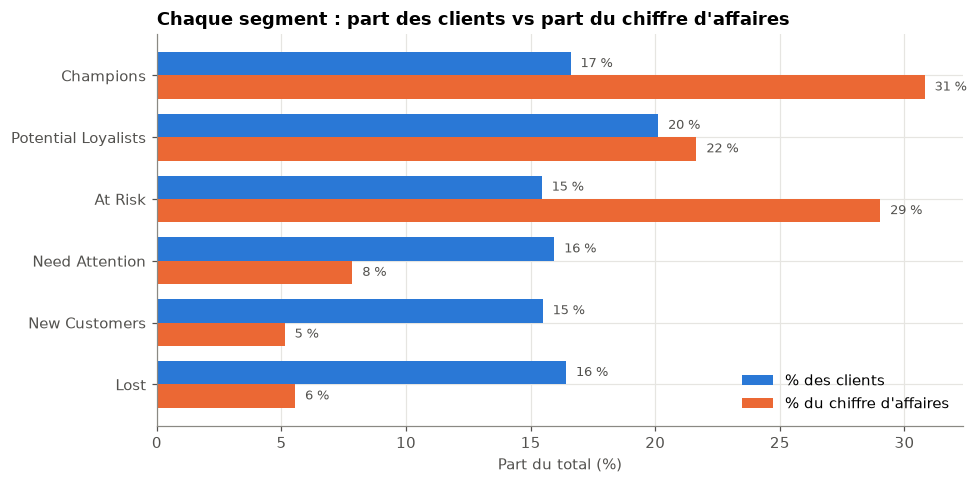

In [6]:
fig, ax = plt.subplots(figsize=(9, 4.5))
y = np.arange(len(segments))
height = 0.38
ax.barh(y - height / 2, segments["pct_clients"], height, color=BLUE, label="% des clients")
ax.barh(y + height / 2, segments["pct_revenu"], height, color=ORANGE, label="% du chiffre d'affaires")
for i, (clients, revenue) in enumerate(zip(segments["pct_clients"], segments["pct_revenu"])):
    ax.text(clients + 0.4, i - height / 2, f"{clients:.0f} %", va="center", fontsize=8.5, color="#52514e")
    ax.text(revenue + 0.4, i + height / 2, f"{revenue:.0f} %", va="center", fontsize=8.5, color="#52514e")
ax.set_yticks(y, segments.index)
ax.invert_yaxis()
ax.set_xlabel("Part du total (%)")
ax.set_title("Chaque segment : part des clients vs part du chiffre d'affaires")
ax.legend(loc="lower right", frameon=False)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "segment_weight.png", bbox_inches="tight")
plt.show()

**Interprétation**
- **Champions** et **At Risk** représentent **32 % des clients mais 60 % du chiffre d'affaires** (~9,2 M R$). Ce sont les deux priorités.
- **At Risk** est le segment le plus critique : un panier moyen équivalent à celui des Champions (~310 R$), mais une inactivité médiane de **380 jours**. C'est une valeur déjà perdue en grande partie, qu'une campagne de réactivation peut chercher à récupérer.
- **New Customers** et **Lost** pèsent 32 % des clients pour seulement 11 % du revenu : paniers faibles (~55 R$), à traiter par des actions peu coûteuses (automatisation, montée en gamme).
- ⚠️ **Limite de lecture :** même chez les Champions, seuls 6 % ont acheté plus d'une fois. Dans ce jeu de données, « Champion » signifie *récent et gros panier*, pas *client fidèle* au sens classique du RFM.

## 4. Le vrai problème : le réachat

### 4.1 Le taux de réachat dépend-il du temps d'observation ?
Un client acquis en 2017 a eu plus de temps pour racheter qu'un client acquis en juillet 2018. On compare le taux de réachat par **cohorte trimestrielle de premier achat**.

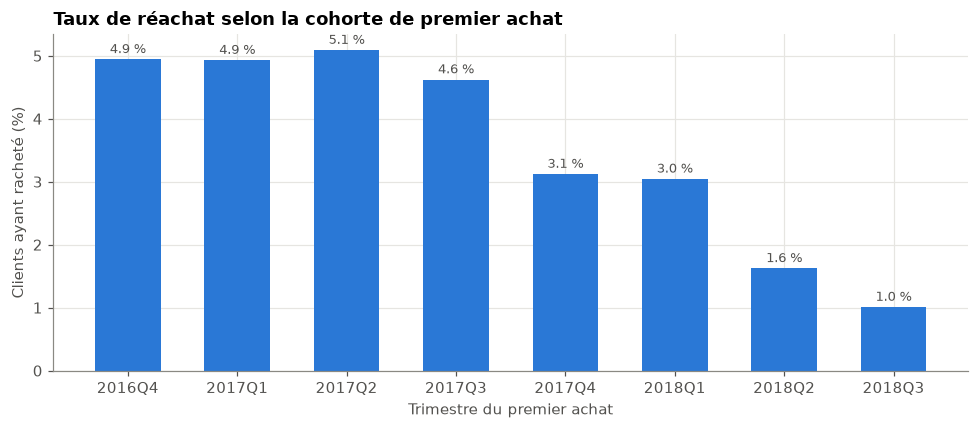

,clients,taux_reachat
cohort,,
2016Q4,263,4.94
2017Q1,4848,4.93
2017Q2,8744,5.09
2017Q3,11813,4.62
2017Q4,16726,3.12
2018Q1,19904,3.04
2018Q2,18966,1.62
2018Q3,12093,1.01


In [7]:
customer_orders = pd.read_sql(
    """
    SELECT c.customer_unique_id, o.order_purchase_timestamp
    FROM orders AS o
    JOIN customers AS c USING (customer_id)
    WHERE o.order_status = 'delivered'
    """,
    engine,
)
cohorts = (
    customer_orders.groupby("customer_unique_id")["order_purchase_timestamp"]
    .agg(first_purchase="min", nb_orders="count")
    .assign(cohort=lambda df: df["first_purchase"].dt.to_period("Q"))
    .groupby("cohort")
    .agg(clients=("nb_orders", "size"), taux_reachat=("nb_orders", lambda s: 100 * (s > 1).mean()))
    .query("clients >= 100")
)

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(cohorts.index.astype(str), cohorts["taux_reachat"], color=BLUE, width=0.6)
for x, v in enumerate(cohorts["taux_reachat"]):
    ax.text(x, v + 0.1, f"{v:.1f} %", ha="center", fontsize=8.5, color="#52514e")
ax.set_title("Taux de réachat selon la cohorte de premier achat")
ax.set_xlabel("Trimestre du premier achat")
ax.set_ylabel("Clients ayant racheté (%)")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "repeat_rate_by_cohort.png", bbox_inches="tight")
plt.show()
cohorts

**Interprétation :** le taux de réachat **dépend fortement du temps d'observation**. Il plafonne autour de **5 %** pour les cohortes observées plus d'un an (2016 T4 – 2017 T3), puis chute mécaniquement pour les cohortes récentes, qui n'ont pas encore eu le temps de racheter (**censure à droite**).

→ Le chiffre global de 3 % sous-estime le potentiel. Le taux de réachat « mature » est d'environ **5 %**, ce qui reste très faible pour un e-commerce généraliste. Cela confirme que le principal enjeu est de **déclencher la deuxième commande**.

### 4.2 Une première expérience satisfaisante fait-elle revenir le client ?
Hypothèse testée : les clients ayant bien noté leur **première** commande rachètent davantage.

In [8]:
first_review = pd.read_sql(
    """
    WITH first_orders AS (
        SELECT DISTINCT ON (c.customer_unique_id) c.customer_unique_id, o.order_id
        FROM orders AS o
        JOIN customers AS c USING (customer_id)
        WHERE o.order_status = 'delivered'
        ORDER BY c.customer_unique_id, o.order_purchase_timestamp
    )
    SELECT f.customer_unique_id, ROUND(AVG(r.review_score)) AS first_review_score
    FROM first_orders AS f
    JOIN reviews AS r USING (order_id)
    GROUP BY f.customer_unique_id
    """,
    engine,
).merge(rfm[["customer_unique_id", "is_repeat_customer"]], on="customer_unique_id")

contingency = pd.crosstab(first_review["first_review_score"].astype(int), first_review["is_repeat_customer"])
chi2, p_value, dof, _ = chi2_contingency(contingency)
cramers_v = np.sqrt(chi2 / (contingency.values.sum() * (min(contingency.shape) - 1)))

summary = pd.DataFrame({
    "clients": contingency.sum(axis=1),
    "taux_reachat (%)": 100 * contingency[True] / contingency.sum(axis=1),
})
print(f"Chi² = {chi2:.1f}, p = {p_value:.3f}, V de Cramér = {cramers_v:.3f}")
summary

Chi² = 8.7, p = 0.070, V de Cramér = 0.010


,clients,taux_reachat (%)
first_review_score,,
1,9058,2.72
2,2835,2.82
3,7686,3.03
4,18365,2.78
5,54796,3.12


**Interprétation :** le taux de réachat varie très peu selon la note de la première commande (2,7 % à 3,1 %). Malgré plus de 90 000 clients, l'écart **n'est pas statistiquement significatif** (test du χ², p ≈ 0,07) et la taille d'effet est négligeable (V de Cramér ≈ 0,01).

→ **La satisfaction n'est pas le levier du réachat.** Un client satisfait ne revient pas spontanément plus souvent qu'un client mécontent. Le levier est à chercher du côté de l'**incitation active** : relance post-achat, recommandations, programme de fidélité, offre sur la deuxième commande.

⚠️ Il s'agit d'une corrélation observationnelle, pas d'un effet causal. Seul un test A/B permettrait de mesurer l'impact réel d'une action.

## 5. Satisfaction : qu'est-ce qui génère les avis négatifs ?

In [9]:
satisfaction = pd.read_sql("SELECT * FROM segment_satisfaction", engine).set_index("segment").reindex(SEGMENT_ORDER)
satisfaction

,note_moyenne,nb_avis,pct_avis_negatifs
segment,,,
Champions,4.15,16630,13.70
Potential Loyalists,4.06,19550,15.30
At Risk,4.13,15284,13.40
Need Attention,4.14,15046,12.70
New Customers,4.25,14483,10.50
Lost,4.23,15367,10.50


Les notes moyennes sont proches entre segments (4,06 à 4,25). Les segments à gros panier (Champions, At Risk, Potential Loyalists) ont un peu plus d'avis négatifs, ce qui suggère un lien avec la complexité des commandes plutôt qu'avec le segment lui-même. On teste le facteur opérationnel le plus probable : **le respect du délai de livraison annoncé**.

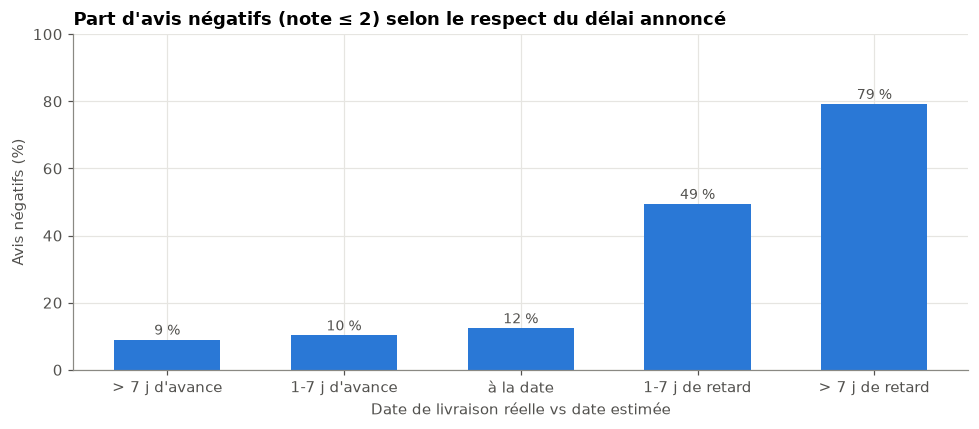

Commandes livrées en retard : 6.7 %


,commandes,note_moyenne,pct_avis_negatifs
delivery,,,
> 7 j d'avance,71334,4.32,8.98
1-7 j d'avance,17319,4.20,10.27
à la date,1291,4.03,12.39
1-7 j de retard,3612,2.71,49.42
> 7 j de retard,2797,1.70,79.19


In [10]:
deliveries = pd.read_sql(
    """
    SELECT
        r.review_score,
        o.order_delivered_customer_date::DATE - o.order_estimated_delivery_date::DATE AS days_vs_estimate
    FROM orders AS o
    JOIN reviews AS r USING (order_id)
    WHERE o.order_status = 'delivered'
      AND o.order_delivered_customer_date IS NOT NULL
    """,
    engine,
)
labels = ["> 7 j d'avance", "1-7 j d'avance", "à la date", "1-7 j de retard", "> 7 j de retard"]
deliveries["delivery"] = pd.cut(deliveries["days_vs_estimate"], bins=[-np.inf, -8, -1, 0, 7, np.inf], labels=labels)
deliveries["negative"] = deliveries["review_score"] <= 2

by_delivery = deliveries.groupby("delivery", observed=True).agg(
    commandes=("review_score", "size"),
    note_moyenne=("review_score", "mean"),
    pct_avis_negatifs=("negative", lambda s: 100 * s.mean()),
)

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(by_delivery.index.astype(str), by_delivery["pct_avis_negatifs"], color=BLUE, width=0.6)
for x, v in enumerate(by_delivery["pct_avis_negatifs"]):
    ax.text(x, v + 1.5, f"{v:.0f} %", ha="center", fontsize=9, color="#52514e")
ax.set_title("Part d'avis négatifs (note ≤ 2) selon le respect du délai annoncé")
ax.set_xlabel("Date de livraison réelle vs date estimée")
ax.set_ylabel("Avis négatifs (%)")
ax.set_ylim(0, 100)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "negative_reviews_by_delivery.png", bbox_inches="tight")
plt.show()

late_share = 100 * (deliveries["days_vs_estimate"] > 0).mean()
print(f"Commandes livrées en retard : {late_share:.1f} %")
by_delivery

**Interprétation :** le retard de livraison est le **principal facteur d'insatisfaction** identifié :
- livré à temps ou en avance : ~9 à 12 % d'avis négatifs ;
- 1 à 7 jours de retard : **49 %** ;
- plus de 7 jours de retard : **~80 %**.

Environ 7 % des commandes sont livrées après la date annoncée. Cette relation est une corrélation (d'autres facteurs, comme la région ou le vendeur, peuvent jouer), mais son ampleur en fait une priorité opérationnelle. Combinée au résultat 4.2, elle conduit à dissocier deux sujets : **la satisfaction relève de la logistique, le réachat du marketing**.

## 6. Géographie et catégories

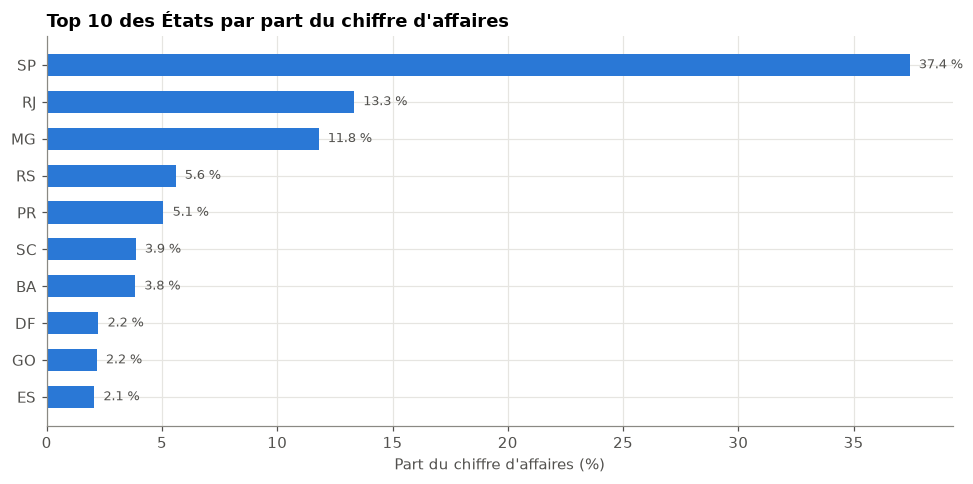

,nb_clients,revenu_total,pct_revenu,revenu_par_client
customer_state,,,,
SP,39149,"5,772,454.12",37.43,147.45
RJ,11914,"2,055,586.40",13.33,172.54
MG,10995,"1,818,932.65",11.79,165.43
RS,5167,"861,886.46",5.59,166.81
PR,4766,"780,868.38",5.06,163.84
SC,3446,"594,893.45",3.86,172.63
BA,3156,"590,993.99",3.83,187.26
DF,2016,"345,250.20",2.24,171.26
GO,1893,"334,486.07",2.17,176.70


In [11]:
geography = (
    pd.read_sql("SELECT * FROM segment_geography", engine)
    .groupby("customer_state")[["nb_clients", "revenu_total"]].sum()
    .assign(
        pct_revenu=lambda df: 100 * df["revenu_total"] / df["revenu_total"].sum(),
        revenu_par_client=lambda df: df["revenu_total"] / df["nb_clients"],
    )
    .sort_values("revenu_total", ascending=False)
)
top_states = geography.head(10)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(top_states.index, top_states["pct_revenu"], color=BLUE, height=0.6)
for i, v in enumerate(top_states["pct_revenu"]):
    ax.text(v + 0.4, i, f"{v:.1f} %", va="center", fontsize=8.5, color="#52514e")
ax.invert_yaxis()
ax.set_title("Top 10 des États par part du chiffre d'affaires")
ax.set_xlabel("Part du chiffre d'affaires (%)")
fig.tight_layout()
plt.show()
top_states

**Interprétation :** São Paulo (SP) concentre **37 % du chiffre d'affaires**, et SP, RJ et MG réunis en représentent plus de 60 %. En revanche, parmi les 10 premiers États, le revenu par client est **le plus faible à SP** (~147 R$) et plus élevé dans les États plus éloignés (BA, GO, etc.). Les frais de livraison, inclus dans le montant, expliquent probablement une partie de cet écart. Le montant ne mesure donc pas uniquement l'appétence d'achat.

In [12]:
categories = pd.read_sql("SELECT * FROM segment_category_analysis", engine)
category_share = (
    categories.pivot_table(index="category", columns="segment", values="revenu_categorie", aggfunc="sum", fill_value=0)
    .pipe(lambda df: 100 * df / df.sum())
)
category_share["Total"] = 100 * categories.groupby("category")["revenu_categorie"].sum() / categories["revenu_categorie"].sum()
category_share.sort_values("Total", ascending=False).head(10)[["Total", "Champions", "At Risk", "New Customers", "Lost"]].round(1)

segment,Total,Champions,At Risk,New Customers,Lost
category,,,,,
health_beauty,9.30,10.70,7.80,10.50,7.30
watches_gifts,8.80,11.10,9.40,4.10,3.40
bed_bath_table,7.70,6.30,7.10,10.20,8.70
sports_leisure,7.20,6.20,6.60,7.10,9.00
computers_accessories,6.70,5.50,7.00,6.60,6.50
furniture_decor,5.40,5.10,5.00,5.10,8.10
housewares,4.70,5.70,2.90,7.40,7.20
cool_stuff,4.60,3.30,7.10,1.10,3.30
auto,4.40,5.00,4.20,5.10,2.60


**Interprétation :** les grandes catégories sont présentes dans tous les segments, mais le mix diffère selon la valeur :
- les segments à forte valeur (Champions, At Risk) sur-représentent les **catégories à ticket élevé** : montres-cadeaux (11 % du revenu des Champions contre 3 % pour Lost), `cool_stuff` ;
- les segments à faible valeur sur-représentent l'**équipement de la maison** (linge, maison, décoration).

→ Pour réactiver les At Risk, les campagnes peuvent cibler les catégories à ticket élevé déjà achetées. Pour faire monter en gamme les New Customers, des recommandations croisées depuis les catégories maison sont une piste.

## 7. Conclusions

### Résultats clés
1. **Le réachat est l'enjeu n°1 :** 97 % des clients n'achètent qu'une fois. Le taux de réachat plafonne à ~5 % même après plus d'un an d'observation.
2. **La valeur est concentrée :** Champions + At Risk = 32 % des clients mais **60 % du chiffre d'affaires**. Les 20 % de clients les plus dépensiers génèrent 54 % du revenu.
3. **At Risk = priorité de réactivation :** ~14 400 clients à fort panier (~310 R$), inactifs depuis ~1 an.
4. **La satisfaction n'explique pas le réachat** (effet négligeable), mais elle est fortement dégradée par les **retards de livraison** (49 à 80 % d'avis négatifs en cas de retard, contre ~10 % sinon).

### Recommandations
| Levier | Cible | Action proposée | KPI de suivi |
|---|---|---|---|
| Déclencher la 2ᵉ commande | New Customers, Potential Loyalists | Offre ou relance automatisée 30-60 jours après le premier achat | Taux de réachat à 90 jours |
| Réactiver | At Risk | Campagne personnalisée sur les catégories déjà achetées | Taux de réactivation, CA récupéré |
| Protéger la valeur | Champions | Accès prioritaire, livraison offerte | Rétention à 6 mois |
| Fiabiliser la livraison | Tous | Estimations de délai plus réalistes, suivi des vendeurs/régions en retard | % de commandes en retard, part d'avis négatifs |

Chaque action devrait être validée par un **test A/B** (groupe témoin) avant d'être généralisée.

### Limites et hypothèses
- **Période tronquée et censure à droite :** données partielles fin 2016 et après août 2018. Les clients récents sont mécaniquement moins fréquents.
- **Fréquence peu informative :** avec 97 % d'acheteurs uniques, le RFM se réduit en pratique à une analyse R × M. Les noms de segments (« Champions ») sont à lire dans ce contexte.
- **Montant = paiements (livraison incluse) :** les clients éloignés de SP paient plus de frais de port, ce qui gonfle leur montant.
- **Seuils de segmentation arbitraires :** les règles R × M sont des choix métier et non le résultat d'une optimisation. Un clustering (k-means sur R et M normalisés) pourrait servir de point de comparaison.
- **Corrélations, pas causalité :** les liens retard → insatisfaction et satisfaction → réachat sont observationnels.
- **Représentativité :** une seule marketplace, au Brésil, sur 2016-2018. Les résultats ne se transposent pas directement à un autre contexte.